In [1]:
import jax
import sys
# put here the path to the folder discovery you're using
sys.path.insert(0, "/home/acastoldi/Tesi-Linux/ng_discovery")
import importlib
importlib.reload(importlib.import_module("discovery"))
import matplotlib.pyplot as plt
import pickle
import numpy as np
import json
import pyarrow

from flowjax.distributions import Normal, Transformed
from discovery import flow

class Pulsar:
    # notes: currently ignores _isort/__isort and gets sorted versions

    columns = ['toas', 'toaerrs', 'residuals', 'freqs', 'backend_flags']
    vector_columns = ['Mmat']
    tensor_columns = []
    # flags are done separately

    # what is _pdist, set in enterprise?
    metadata = ['name', 'dm', 'dmx', 'pdist', 'pos', 'phi', 'theta', 'fitpars', 'setpars']

    def __init__(self):
        pass

    def __str__(self):
        return f'<Pulsar {self.name}: {len(self.residuals)} res, {self.Mmat.shape[1]} pars>'

    def __repr__(self):
        return str(self)

    @classmethod
    def read_feather(cls, filename):
        f = pyarrow.feather.read_table(filename)
        self = Pulsar()

        for array in Pulsar.columns:
            if array in f.column_names:
                setattr(self, array, f[array].to_numpy())

        for array in Pulsar.vector_columns:
            cols = [c for c in f.column_names if c.startswith(array)]
            setattr(self, array, np.array([f[col].to_numpy() for col in cols]).swapaxes(0,1).copy())

        for array in Pulsar.tensor_columns:
            rows = sorted(set(['_'.join(c.split('_')[:-1]) for c in f.column_names if c.startswith(array)]))
            cols = [[c for c in f.column_names if c.startswith(row)] for row in rows]
            setattr(self, array,
                    np.array([[f[col].to_numpy() for col in row] for row in cols]).swapaxes(0,2).swapaxes(1,2).copy())

        self.flags = {}
        for array in [c for c in f.column_names if c.startswith('flags_')]:
            self.flags['_'.join(array.split('_')[1:])] = f[array].to_numpy().astype('U')

        meta = json.loads(f.schema.metadata[b'json'])

        for attr in Pulsar.metadata:
            if attr in meta:
                setattr(self, attr, meta[attr])
            # else:
            #     print(f'Pulsar.read_feather: cannot find {attr} in feather file {filename}.')

        if 'noisedict' in meta:
            setattr(self, 'noisedict', meta['noisedict'])

        setattr(self, 'mintoa', np.min(self.toas))
        setattr(self, 'maxtoa', np.max(self.toas))

        return self

    to_list = lambda a: a.tolist() if isinstance(a, np.ndarray) else a

    def save_feather(self, filename, noisedict=None):
        pydict = {array: getattr(self, array) for array in Pulsar.columns}
 
        pydict.update({f'{array}_{i}': getattr(self, array)[:,i] for array in Pulsar.vector_columns
                                                                 for i in range(getattr(self, array).shape[1])})
    
        pydict.update({f'{array}_{i}_{j}': getattr(self, array)[:,i,j] for array in Pulsar.tensor_columns
                                                                 for i in range(getattr(self, array).shape[1])
                                                                 for j in range(getattr(self, array).shape[2])})

        pydict.update({f'flags_{flag}': self.flags[flag] for flag in self.flags})

        meta = {}

        for attr in Pulsar.metadata:
            if hasattr(self, attr):
                meta[attr] = Pulsar.to_list(getattr(self, attr))
            # else:
            #     print(f'Pulsar.save_feather: cannot find {attr} in Pulsar {self.name}.')

        # use attribute if present
        noisedict = getattr(self, 'noisedict', None) if noisedict is None else noisedict
        if noisedict:
            meta['noisedict'] = {par: val for par, val in noisedict.items() if par.startswith(self.name)}

        pyarrow.feather.write_feather(pyarrow.Table.from_pydict(pydict, metadata={'json': json.dumps(meta)}),
                                      filename)

I0000 00:00:1782313295.898697   25289 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1782313295.908382   25289 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1782313295.912422   25289 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1782313295.946884   25289 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


In [2]:
import glob

filename = 'feathers/fake_100_psrs_10yrs_gauss_gwb_7WN_nogwb/*'

psrfiles = sorted(glob.glob(filename))

d_psrs = [Pulsar.read_feather(f) for f in psrfiles]
print('Number of pulsars:', len(d_psrs))

Number of pulsars: 100


noise dict for J0013-1303 : {'J0013-1303_backend_0_efac': 1, 'J0013-1303_backend_0_log10_tnequad': -12.0, 'J0013-1303_backend_1_efac': 1, 'J0013-1303_backend_1_log10_tnequad': -12.0, 'J0013-1303_red_components': 30, 'J0013-1303_dm_gp_components': 100}
Number of residuals: 1000


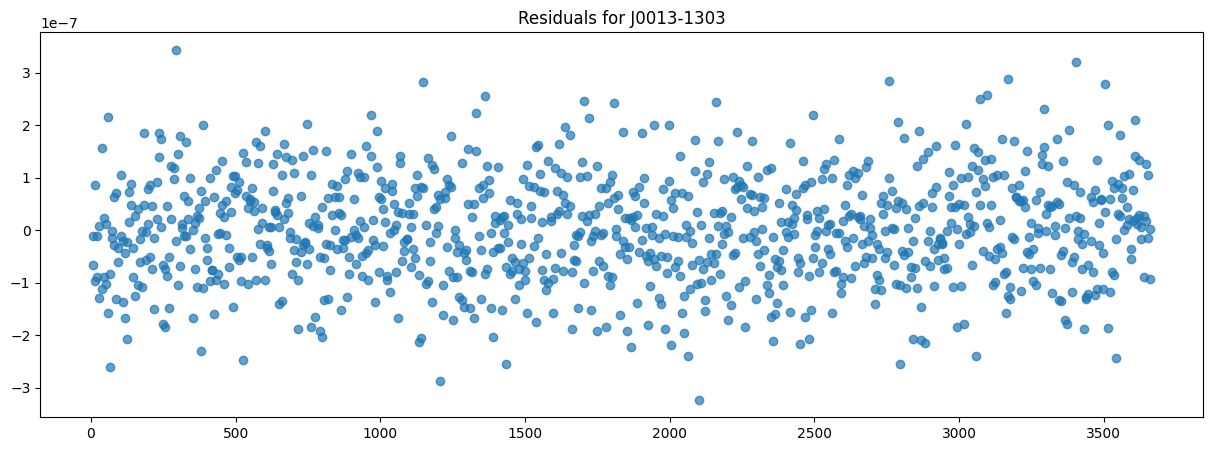

noise dict for J0024+6046 : {'J0024+6046_backend_0_efac': 1, 'J0024+6046_backend_0_log10_tnequad': -12.0, 'J0024+6046_red_components': 30, 'J0024+6046_dm_gp_components': 100}
Number of residuals: 500


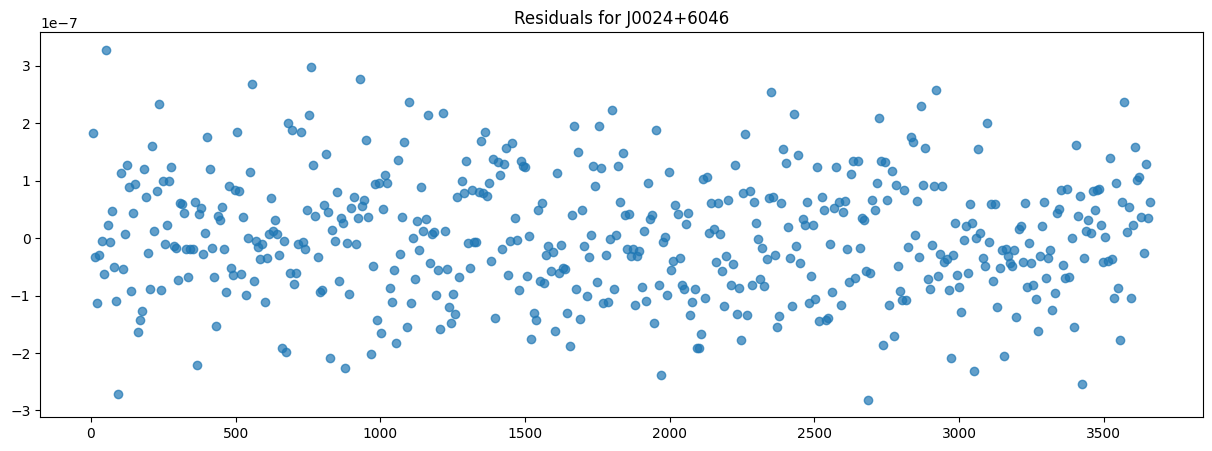

noise dict for J0032-6551 : {'J0032-6551_backend_0_efac': 1, 'J0032-6551_backend_0_log10_tnequad': -12.0, 'J0032-6551_red_components': 30, 'J0032-6551_dm_gp_components': 100}
Number of residuals: 500


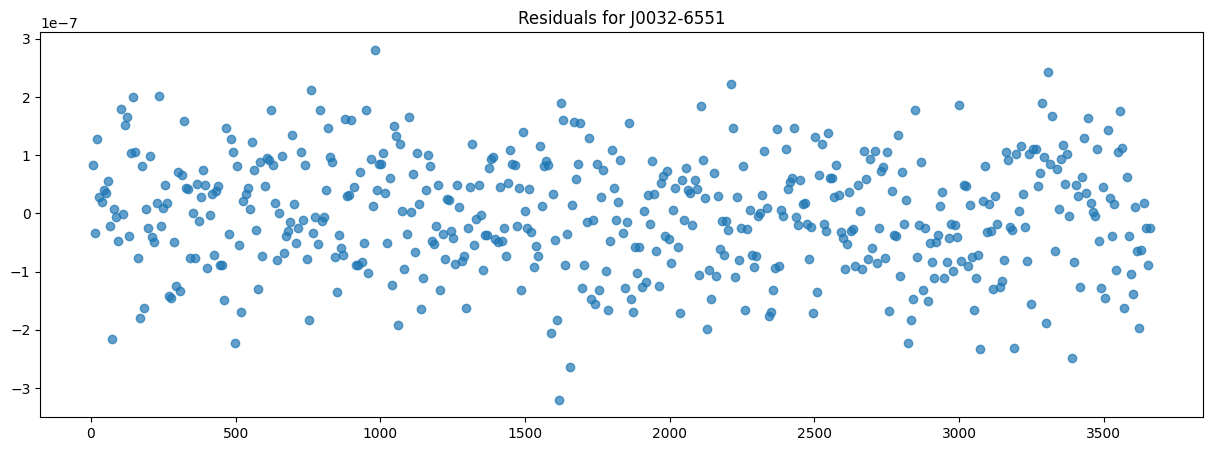

noise dict for J0043+1095 : {'J0043+1095_backend_0_efac': 1, 'J0043+1095_backend_0_log10_tnequad': -12.0, 'J0043+1095_backend_1_efac': 1, 'J0043+1095_backend_1_log10_tnequad': -12.0, 'J0043+1095_red_components': 30, 'J0043+1095_dm_gp_components': 100}
Number of residuals: 1000


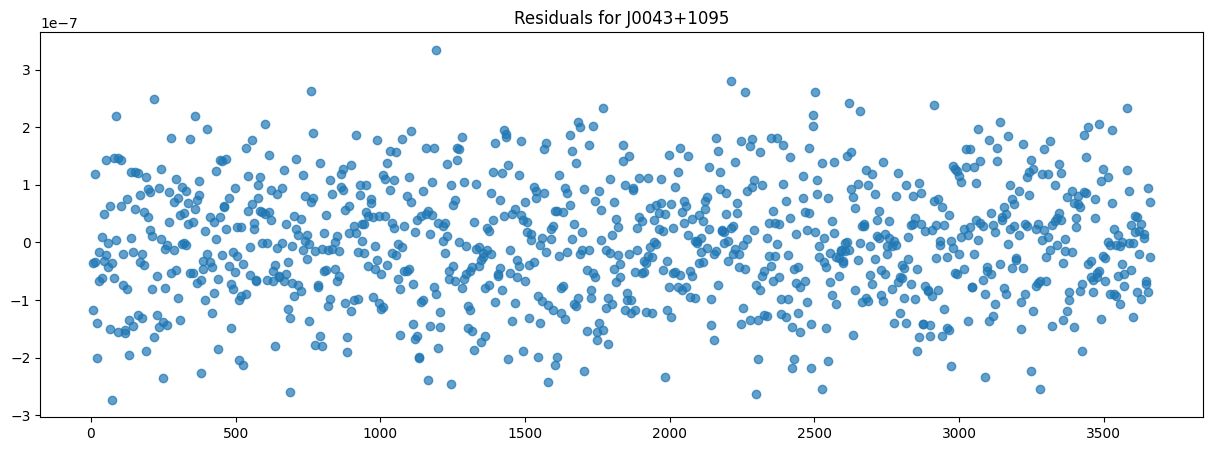

noise dict for J0102-2934 : {'J0102-2934_backend_0_efac': 1, 'J0102-2934_backend_0_log10_tnequad': -12.0, 'J0102-2934_red_components': 30, 'J0102-2934_dm_gp_components': 100}
Number of residuals: 500


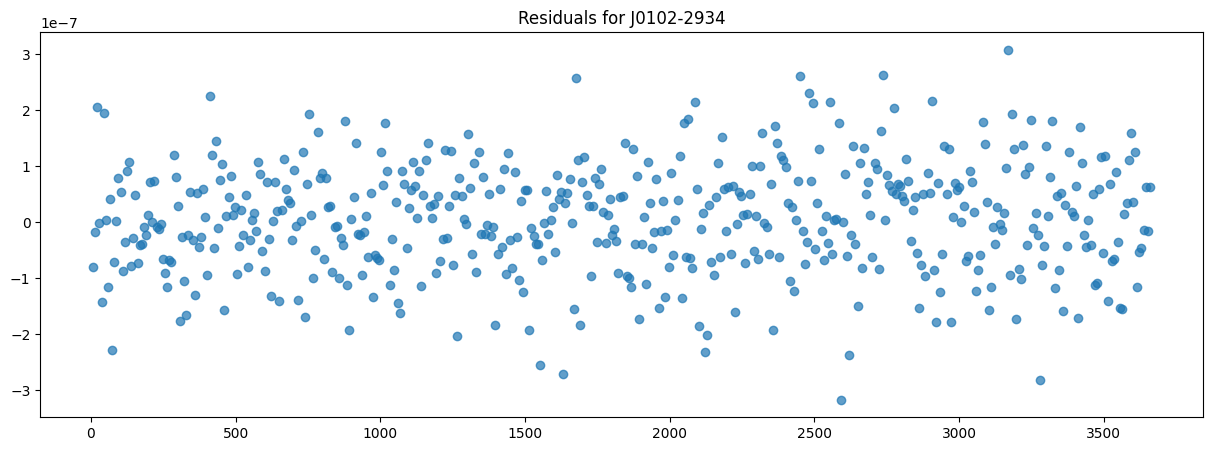

noise dict for J0114+3759 : {'J0114+3759_backend_0_efac': 1, 'J0114+3759_backend_0_log10_tnequad': -12.0, 'J0114+3759_red_components': 30, 'J0114+3759_dm_gp_components': 100}
Number of residuals: 500


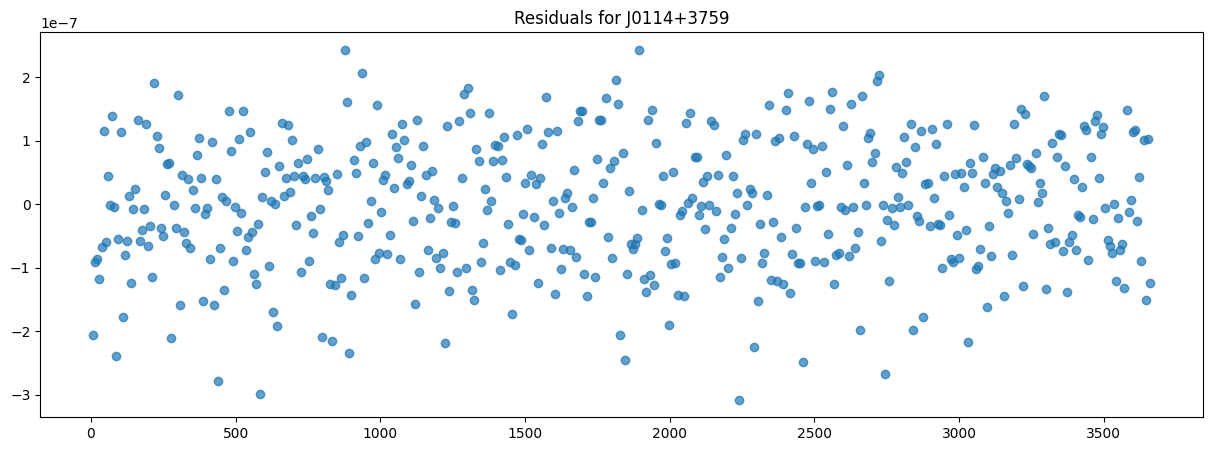

noise dict for J0133-0401 : {'J0133-0401_backend_0_efac': 1, 'J0133-0401_backend_0_log10_tnequad': -12.0, 'J0133-0401_red_components': 30, 'J0133-0401_dm_gp_components': 100}
Number of residuals: 500


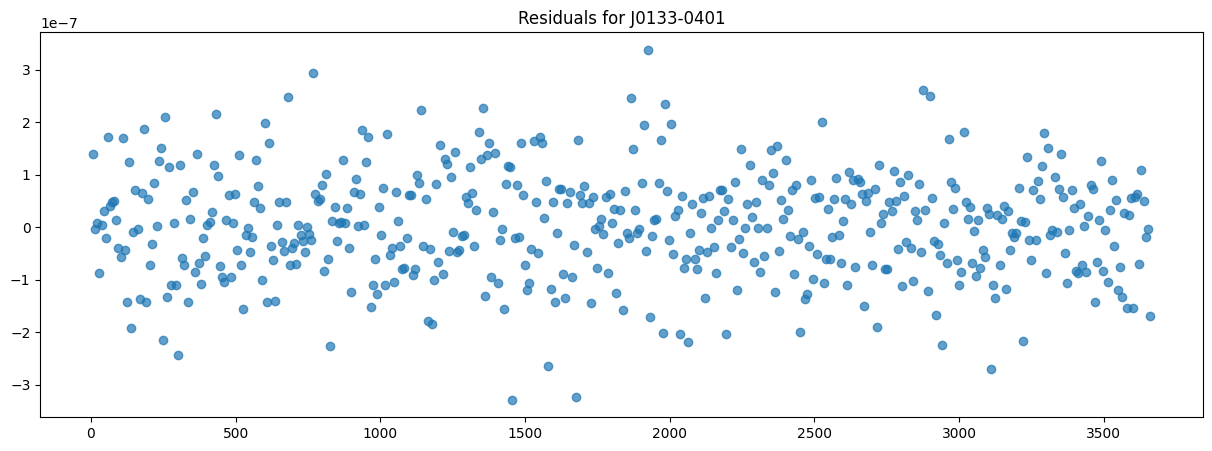

noise dict for J0152-4859 : {'J0152-4859_backend_0_efac': 1, 'J0152-4859_backend_0_log10_tnequad': -12.0, 'J0152-4859_backend_1_efac': 1, 'J0152-4859_backend_1_log10_tnequad': -12.0, 'J0152-4859_red_components': 30, 'J0152-4859_dm_gp_components': 100}
Number of residuals: 1000


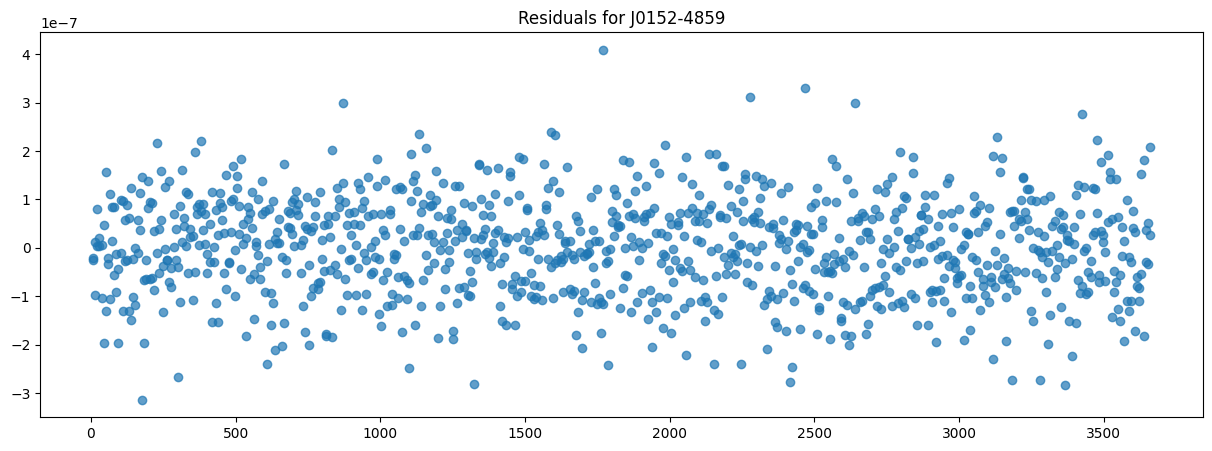

noise dict for J0203+2049 : {'J0203+2049_backend_0_efac': 1, 'J0203+2049_backend_0_log10_tnequad': -12.0, 'J0203+2049_red_components': 30, 'J0203+2049_dm_gp_components': 100}
Number of residuals: 500


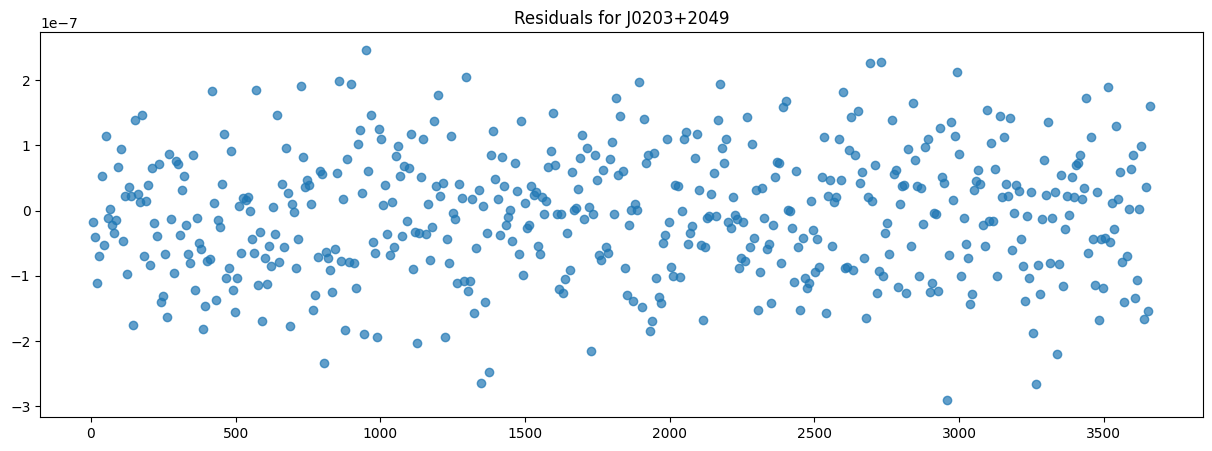

noise dict for J0222-1927 : {'J0222-1927_backend_0_efac': 1, 'J0222-1927_backend_0_log10_tnequad': -12.0, 'J0222-1927_backend_1_efac': 1, 'J0222-1927_backend_1_log10_tnequad': -12.0, 'J0222-1927_red_components': 30, 'J0222-1927_dm_gp_components': 100}
Number of residuals: 1000


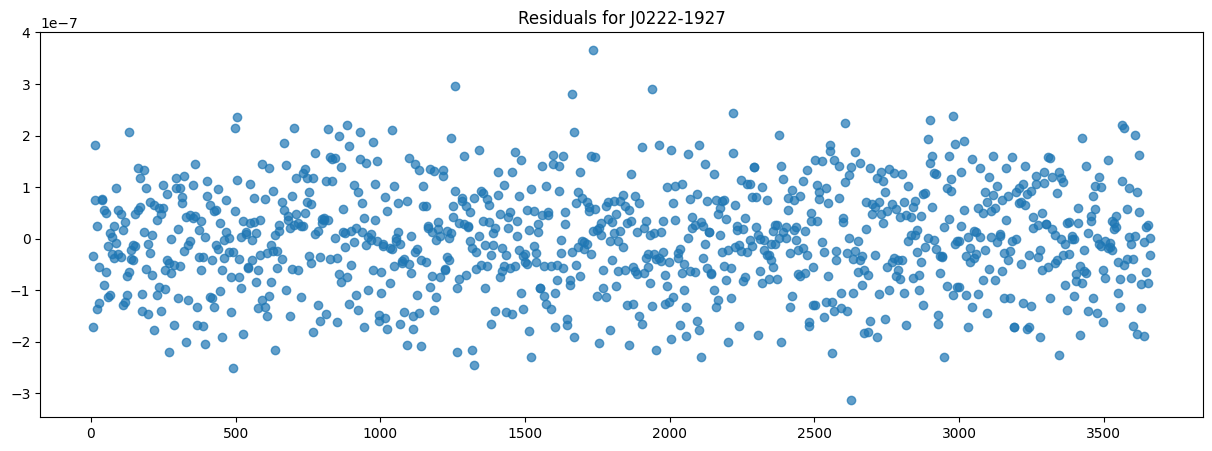

In [3]:
for psr in d_psrs[0:10]:
    plt.figure(figsize=(15, 5))
    plt.title(f"Residuals for {psr.name}")
    plt.scatter(psr.toas / (3600*24), psr.residuals, alpha=0.7)
    print('noise dict for', psr.name, ':', psr.noisedict)
    print("Number of residuals:", len(psr.residuals))
    plt.show()